<a href="https://colab.research.google.com/github/panchagnulavinutna/PlagarismChecker/blob/main/Audio_Deepfake.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install librosa torch torchaudio transformers numpy pandas matplotlib scikit-learn

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{\r\n  "username": "pvinutna",\r\n  "key": "KGAT_6bd1894d7b2af4fb9f41f70ec2ad0ffb"\r\n}'}

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets list

ref                                                            title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
nalisha/job-salary-prediction-dataset                          Job Salary Prediction Dataset                          3144815  2026-03-16 19:54:33.843000           3877         90                1  
ssssws/chocolate-sales-dataset-2023-2024                       Chocolate Sales Dataset 2023 - 2024                   24420255  2026-03-07 04:58:02.387000           7309        122                1  
sharmajicoder/student-mental-health-and-burnout                Student Mental Health and Burnout                    137596875  2026-03-18 19:03:34.140000           1307         35                1  
grand

In [ ]:
!kaggle datasets download -d awsaf49/asvpoof-2019-dataset

Dataset URL: https://www.kaggle.com/datasets/awsaf49/asvpoof-2019-dataset
License(s): ODC Attribution License (ODC-By)
100% 23.6G/23.6G [03:24<00:00, 124MB/s]



In [ ]:
!unzip asvpoof-2019-dataset.zip -d /content/data

Streaming output truncated to the last 5000 lines.
  inflating: /content/data/PA/PA/ASVspoof2019_PA_train/flac/PA_T_0049005.flac  
  inflating: /content/data/PA/PA/ASVspoof2019_PA_train/flac/PA_T_0049006.flac  
  inflating: /content/data/PA/PA/ASVspoof2019_PA_train/flac/PA_T_0049007.flac  
  inflating: /content/data/PA/PA/ASVspoof2019_PA_train/flac/PA_T_0049008.flac  
  inflating: /content/data/PA/PA/ASVspoof2019_PA_train/flac/PA_T_0049009.flac  
  inflating: /content/data/PA/PA/ASVspoof2019_PA_train/flac/PA_T_0049010.flac  
  inflating: /content/data/PA/PA/ASVspoof2019_PA_train/flac/PA_T_0049011.flac  
  inflating: /content/data/PA/PA/ASVspoof2019_PA_train/flac/PA_T_0049012.flac  
  inflating: /content/data/PA/PA/ASVspoof2019_PA_train/flac/PA_T_0049013.flac  
  inflating: /content/data/PA/PA/ASVspoof2019_PA_train/flac/PA_T_0049014.flac  
  inflating: /content/data/PA/PA/ASVspoof2019_PA_train/flac/PA_T_0049015.flac  
  inflating: /content/data/PA/PA/ASVspoof2019_PA_train/flac/PA_T_0049

In [ ]:
import os

base_path = "/content/data"

for root, dirs, files in os.walk(base_path):
    level = root.replace(base_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 3:
        subindent = ' ' * 2 * (level + 1)
        for file in files[:5]:  # show first 5 files only
            print(f"{subindent}{file}")

data/
  LICENSE_text.txt
  asvspoof2019_evaluation_plan.pdf
  README.txt
  asvspoof2019_Interspeech2019_submission.pdf
  LA/
    LA/
      README.LA.txt
      ASVspoof2019_LA_cm_protocols/
      ASVspoof2019_LA_train/
        flac/
      ASVspoof2019_LA_asv_protocols/
      ASVspoof2019_LA_asv_scores/
      ASVspoof2019_LA_eval/
        flac/
      ASVspoof2019_LA_dev/
        flac/
  PA/
    PA/
      README.PA.txt
      ASVspoof2019_PA_cm_protocols/
      ASVspoof2019_PA_asv_protocols/
      ASVspoof2019_PA_dev/
        flac/
      ASVspoof2019_PA_train/
        flac/
      ASVspoof2019_PA_eval/
        flac/
      ASVspoof2019_PA_asv_scores/


In [ ]:
for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith(".txt") or "protocol" in file.lower():
            print(os.path.join(root, file))

/content/data/LICENSE_text.txt
/content/data/README.txt
/content/data/LA/LA/README.LA.txt
/content/data/LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt
/content/data/LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.dev.trl.txt
/content/data/LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.eval.trl.txt
/content/data/LA/LA/ASVspoof2019_LA_train/LICENSE.txt
/content/data/LA/LA/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.eval.male.trl.txt
/content/data/LA/LA/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.dev.female.trl.txt
/content/data/LA/LA/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.eval.female.trn.txt
/content/data/LA/LA/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.dev.male.trl.txt
/content/data/LA/LA/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.dev.gi.trl.txt
/content/data/LA/LA/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.dev.male.trn.txt
/content/data/LA/LA/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.dev.female.trn.tx

In [ ]:
import os

base_path = "/content/data"

for root, dirs, files in os.walk(base_path):
    level = root.replace(base_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 2 * (level + 1)
    for file in files[:5]:
        print(f"{subindent}{file}")

data/
  LICENSE_text.txt
  asvspoof2019_evaluation_plan.pdf
  README.txt
  asvspoof2019_Interspeech2019_submission.pdf
  LA/
    LA/
      README.LA.txt
      ASVspoof2019_LA_cm_protocols/
        ASVspoof2019.LA.cm.train.trn.txt
        ASVspoof2019.LA.cm.dev.trl.txt
        ASVspoof2019.LA.cm.eval.trl.txt
      ASVspoof2019_LA_train/
        LICENSE.txt
        flac/
          LA_T_9085144.flac
          LA_T_1167878.flac
          LA_T_4097061.flac
          LA_T_4837104.flac
          LA_T_2784825.flac
      ASVspoof2019_LA_asv_protocols/
        ASVspoof2019.LA.asv.eval.male.trl.txt
        ASVspoof2019.LA.asv.dev.female.trl.txt
        ASVspoof2019.LA.asv.eval.female.trn.txt
        ASVspoof2019.LA.asv.dev.male.trl.txt
        ASVspoof2019.LA.asv.dev.gi.trl.txt
      ASVspoof2019_LA_asv_scores/
        ASVspoof2019.LA.asv.dev.gi.trl.scores.txt
        ASVspoof2019.LA.asv.eval.gi.trl.scores.txt
      ASVspoof2019_LA_eval/
        LICENSE.txt
        flac/
          LA_E_4815361.fl

In [ ]:
for root, dirs, files in os.walk("/content/data"):
    for file in files:
        if file.endswith(".txt"):
            print(os.path.join(root, file))

/content/data/LICENSE_text.txt
/content/data/README.txt
/content/data/LA/LA/README.LA.txt
/content/data/LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt
/content/data/LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.dev.trl.txt
/content/data/LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.eval.trl.txt
/content/data/LA/LA/ASVspoof2019_LA_train/LICENSE.txt
/content/data/LA/LA/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.eval.male.trl.txt
/content/data/LA/LA/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.dev.female.trl.txt
/content/data/LA/LA/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.eval.female.trn.txt
/content/data/LA/LA/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.dev.male.trl.txt
/content/data/LA/LA/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.dev.gi.trl.txt
/content/data/LA/LA/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.dev.male.trn.txt
/content/data/LA/LA/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.dev.female.trn.tx

In [ ]:
# Check if zip file still exists
import os
print(os.listdir("/content"))

['.config', 'asvpoof-2019-dataset.zip', 'data', 'sample_data']


In [ ]:
# Check total size of /content/data to see if anything is actually there
import subprocess
result = subprocess.run(['du', '-sh', '/content/data'], capture_output=True, text=True)
print(result.stdout)
print(result.stderr)

25G	/content/data




In [ ]:
# Check if the zip file downloaded properly
result2 = subprocess.run(['ls', '-lh', '/content'], capture_output=True, text=True)
print(result2.stdout)

total 24G
-rw-r--r-- 1 root root  24G Jun 21  2022 asvpoof-2019-dataset.zip
drwxr-xr-x 4 root root 4.0K Mar 28 11:51 data
drwxr-xr-x 1 root root 4.0K Mar 23 13:29 sample_data



In [ ]:
import os
for root, dirs, files in os.walk("/content/data"):
    level = root.replace("/content/data", '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 2 * (level + 1)
    for file in files[:3]:
        print(f"{subindent}{file}")

data/
  LICENSE_text.txt
  asvspoof2019_evaluation_plan.pdf
  README.txt
  LA/
    LA/
      README.LA.txt
      ASVspoof2019_LA_cm_protocols/
        ASVspoof2019.LA.cm.train.trn.txt
        ASVspoof2019.LA.cm.dev.trl.txt
        ASVspoof2019.LA.cm.eval.trl.txt
      ASVspoof2019_LA_train/
        LICENSE.txt
        flac/
          LA_T_9085144.flac
          LA_T_1167878.flac
          LA_T_4097061.flac
      ASVspoof2019_LA_asv_protocols/
        ASVspoof2019.LA.asv.eval.male.trl.txt
        ASVspoof2019.LA.asv.dev.female.trl.txt
        ASVspoof2019.LA.asv.eval.female.trn.txt
      ASVspoof2019_LA_asv_scores/
        ASVspoof2019.LA.asv.dev.gi.trl.scores.txt
        ASVspoof2019.LA.asv.eval.gi.trl.scores.txt
      ASVspoof2019_LA_eval/
        LICENSE.txt
        flac/
          LA_E_4815361.flac
          LA_E_9185085.flac
          LA_E_5285259.flac
      ASVspoof2019_LA_dev/
        LICENSE.txt
        flac/
          LA_D_7603562.flac
          LA_D_7796753.flac
          LA_D

In [ ]:
import pandas as pd

protocol_path = "/content/data/LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt"

df = pd.read_csv(protocol_path, sep=" ", header=None)
df.columns = ["speaker_id", "audio_file", "unknown", "attack_type", "label"]
print(df.head())
print("\nLabel counts:")
print(df["label"].value_counts())

  speaker_id    audio_file unknown attack_type     label
0    LA_0079  LA_T_1138215       -           -  bonafide
1    LA_0079  LA_T_1271820       -           -  bonafide
2    LA_0079  LA_T_1272637       -           -  bonafide
3    LA_0079  LA_T_1276960       -           -  bonafide
4    LA_0079  LA_T_1341447       -           -  bonafide

Label counts:
label
spoof       22800
bonafide     2580
Name: count, dtype: int64


In [ ]:
import os

audio_base = "/content/data/LA/LA/ASVspoof2019_LA_train/flac"

df["audio_path"] = df["audio_file"].apply(lambda x: os.path.join(audio_base, x + ".flac"))

# Verify paths exist
print("Sample path:", df["audio_path"].iloc[0])
print("File exists:", os.path.exists(df["audio_path"].iloc[0]))
print("Total samples:", len(df))

Sample path: /content/data/LA/LA/ASVspoof2019_LA_train/flac/LA_T_1138215.flac
File exists: True
Total samples: 25380


In [ ]:
import librosa
import numpy as np

def extract_features_multidomain(audio_path, sr=16000, n_mfcc=40, max_len=200):
    try:
        y, sr = librosa.load(audio_path, sr=sr)
        y, _ = librosa.effects.trim(y)

        def pad(feature):
            if feature.shape[1] < max_len:
                feature = np.pad(feature, ((0, 0), (0, max_len - feature.shape[1])))
            else:
                feature = feature[:, :max_len]
            return feature

        # 1. MFCC — spectral (vocal tract shape)
        mfcc = pad(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40))

        # 2. Mel Spectrogram — spectral
        mel = pad(librosa.power_to_db(
            librosa.feature.melspectrogram(y=y, sr=sr, n_mels=40),
            ref=np.max
        ))

        # 3. Micro-prosody — pitch (F0) variations
        # Captures tiny pitch changes humans make naturally
        f0, voiced_flag, _ = librosa.pyin(
            y, fmin=librosa.note_to_hz('C2'),
            fmax=librosa.note_to_hz('C7'),
            sr=sr
        )
        f0 = np.nan_to_num(f0)                          # replace NaN with 0
        f0 = f0.reshape(1, -1)                          # (1, T)
        f0 = pad(np.tile(f0, (40, 1)))                  # (40, T)

        # 4. Vocal tract dynamics — LPC-based spectral envelope
        # Captures throat/mouth physical production characteristics
        lpc_order = 16
        lpc_coeffs = librosa.lpc(y, order=lpc_order)
        lpc_feature = np.abs(np.fft.fft(lpc_coeffs, n=max_len))[:40]
        lpc_feature = lpc_feature.reshape(40, 1)
        lpc_2d = np.tile(lpc_feature, (1, max_len))     # (40, 200)

        # 5. Breathing + Phase irregularities
        # RMS energy dips = breathing pauses
        # Phase from STFT = wave alignment check
        rms = librosa.feature.rms(y=y)
        stft = librosa.stft(y)
        phase = np.angle(stft)[:40, :]

        # Combine breathing (RMS) with phase irregularities
        rms_tiled = pad(np.tile(rms, (40, 1)))          # (40, T)
        phase_padded = pad(phase)                        # (40, T)

        # Weighted sum: breathing + phase
        breathing_phase = 0.5 * rms_tiled + 0.5 * phase_padded  # (40, 200)

        # Stack all 5 domains → (5, 40, 200)
        features = np.stack([
            mfcc,            # spectral
            mel,             # spectral
            f0,              # micro-prosody
            lpc_2d,          # vocal tract dynamics
            breathing_phase  # breathing + phase
        ], axis=0).astype(np.float32)

        return features

    except Exception as e:
        print(f"Error: {audio_path} → {e}")
        return None

# Test
feat = extract_features_multidomain(df["audio_path"].iloc[0])
print("Shape:", feat.shape)   # (5, 40, 200)
print("dtype:", feat.dtype)

Shape: (5, 40, 200)
dtype: float32


In [ ]:
from tqdm import tqdm
import numpy as np
import pandas as pd
import gc

# Balanced subset — equal real and fake
df_real = df[df["label"] == "bonafide"]
df_fake = df[df["label"] == "spoof"]

print(f"Total Real: {len(df_real)} | Total Fake: {len(df_fake)}")

# Take equal numbers for balance
df_real_sub = df_real.sample(n=1500, random_state=42)
df_fake_sub = df_fake.sample(n=1500, random_state=42)

df_sub = pd.concat([df_real_sub, df_fake_sub]).sample(
    frac=1, random_state=42
).reset_index(drop=True)

print(f"Subset size: {len(df_sub)}")
print(df_sub["label"].value_counts())

X_multi = []
y_multi = []

for i, row in tqdm(df_sub.iterrows(), total=len(df_sub)):
    feat = extract_features_multidomain(row["audio_path"])
    if feat is not None:
        X_multi.append(feat)
        y_multi.append(0 if row["label"] == "bonafide" else 1)

X_multi = np.array(X_multi, dtype=np.float32)
y_multi = np.array(y_multi)

print("Shape:", X_multi.shape)
print("Real:", (y_multi==0).sum(), "| Fake:", (y_multi==1).sum())

np.save("/content/X_multi.npy", X_multi)
np.save("/content/y_multi.npy", y_multi)
print("Saved!")

Total Real: 2580 | Total Fake: 22800
Subset size: 3000
label
spoof       1500
bonafide    1500
Name: count, dtype: int64


100%|██████████| 3000/3000 [58:00<00:00,  1.16s/it]


Shape: (3000, 5, 40, 200)
Real: 1500 | Fake: 1500
Saved!


In [ ]:
import torch
import torch.nn as nn

class AttentionFusion(nn.Module):
    def __init__(self, num_domains=5, feature_dim=128):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(feature_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
    def forward(self, domain_features):
        stacked = torch.stack(domain_features, dim=1)
        weights = torch.softmax(self.attention(stacked), dim=1)
        return (stacked * weights).sum(dim=1), weights.squeeze(-1)


class DeepTraceAudioV2(nn.Module):
    def __init__(self, num_domains=5, input_dim=40, seq_len=200,
                 num_heads=4, num_layers=2, num_classes=2):
        super().__init__()

        self.input_projs = nn.ModuleList([
            nn.Linear(input_dim, 128) for _ in range(num_domains)
        ])
        self.pos_embeddings = nn.ParameterList([
            nn.Parameter(torch.randn(1, seq_len, 128))
            for _ in range(num_domains)
        ])

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=128, nhead=num_heads, dim_feedforward=256,
            dropout=0.1, batch_first=True
        )
        self.transformers = nn.ModuleList([
            nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
            for _ in range(num_domains)
        ])

        self.fusion = AttentionFusion(num_domains=num_domains, feature_dim=128)

        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        domain_outputs = []
        for i in range(x.shape[1]):
            xi = x[:, i, :, :].permute(0, 2, 1)      # (batch, 200, 40)
            xi = self.input_projs[i](xi)               # (batch, 200, 128)
            xi = xi + self.pos_embeddings[i]
            xi = self.transformers[i](xi)
            xi = xi.mean(dim=1)                        # (batch, 128)
            domain_outputs.append(xi)

        fused, attn_weights = self.fusion(domain_outputs)
        return self.classifier(fused), attn_weights


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_v2 = DeepTraceAudioV2().to(device)
print("Model ready on:", device)
print(f"Parameters: {sum(p.numel() for p in model_v2.parameters()):,}")

Model ready on: cpu
Parameters: 1,495,747


In [ ]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torch
import gc

class MultiDomainDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

X_tr, X_vl, y_tr, y_vl = train_test_split(
    X_multi, y_multi, test_size=0.2,
    random_state=42, stratify=y_multi
)

del X_multi, y_multi
gc.collect()

# Weighted sampler so model sees equal real/fake per batch
class_counts = np.bincount(y_tr)
weights = 1.0 / class_counts
sample_weights = torch.tensor([weights[y] for y in y_tr], dtype=torch.float32)
sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

train_loader_v2 = DataLoader(
    MultiDomainDataset(X_tr, y_tr),
    batch_size=32,
    sampler=sampler
)
val_loader_v2 = DataLoader(
    MultiDomainDataset(X_vl, y_vl),
    batch_size=32,
    shuffle=False
)

print("Train:", X_tr.shape, "| Val:", X_vl.shape)
print("Train — Real:", (y_tr==0).sum(), "| Fake:", (y_tr==1).sum())
print("Val   — Real:", (y_vl==0).sum(), "| Fake:", (y_vl==1).sum())

Train: (2400, 5, 40, 200) | Val: (600, 5, 40, 200)
Train — Real: 1200 | Fake: 1200
Val   — Real: 300 | Fake: 300


In [ ]:
import torch.optim as optim

# Weighted loss — penalizes mistakes on minority class more
class_counts = np.bincount(y_tr)
class_weights = torch.tensor(
    [1.0/class_counts[0], 1.0/class_counts[1]],
    dtype=torch.float32
).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer_v2 = optim.Adam(model_v2.parameters(), lr=3e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer_v2, step_size=5, gamma=0.5)

def train_v2(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs, _ = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (outputs.argmax(1) == y_batch).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

def eval_v2(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs, _ = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item()
            correct += (outputs.argmax(1) == y_batch).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

EPOCHS = 15
best_val_acc = 0

for epoch in range(EPOCHS):
    tr_loss, tr_acc = train_v2(model_v2, train_loader_v2, optimizer_v2, criterion)
    vl_loss, vl_acc = eval_v2(model_v2, val_loader_v2, criterion)
    scheduler.step()

    # Save best model
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model_v2.state_dict(), "/content/best_model_v2.pth")

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | "
          f"Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f}")

print(f"\nBest Val Accuracy: {best_val_acc:.4f}")

# Load best model for evaluation
model_v2.load_state_dict(torch.load("/content/best_model_v2.pth"))
print("Best model loaded for evaluation!")

Epoch 1/15 | Train Loss: 0.6941 Acc: 0.5029 | Val Loss: 0.6793 Acc: 0.5017
Epoch 2/15 | Train Loss: 0.4700 Acc: 0.7783 | Val Loss: 0.2339 Acc: 0.9300
Epoch 3/15 | Train Loss: 0.2704 Acc: 0.9004 | Val Loss: 0.1778 Acc: 0.9317
Epoch 4/15 | Train Loss: 0.1519 Acc: 0.9446 | Val Loss: 0.1058 Acc: 0.9633
Epoch 5/15 | Train Loss: 0.1481 Acc: 0.9487 | Val Loss: 0.0885 Acc: 0.9700
Epoch 6/15 | Train Loss: 0.0738 Acc: 0.9746 | Val Loss: 0.0880 Acc: 0.9633
Epoch 7/15 | Train Loss: 0.0623 Acc: 0.9767 | Val Loss: 0.0791 Acc: 0.9700
Epoch 8/15 | Train Loss: 0.0432 Acc: 0.9833 | Val Loss: 0.1051 Acc: 0.9650
Epoch 9/15 | Train Loss: 0.1242 Acc: 0.9529 | Val Loss: 0.0697 Acc: 0.9717
Epoch 10/15 | Train Loss: 0.0500 Acc: 0.9833 | Val Loss: 0.0693 Acc: 0.9733
Epoch 11/15 | Train Loss: 0.0315 Acc: 0.9896 | Val Loss: 0.0647 Acc: 0.9767
Epoch 12/15 | Train Loss: 0.0353 Acc: 0.9908 | Val Loss: 0.0456 Acc: 0.9833
Epoch 13/15 | Train Loss: 0.0322 Acc: 0.9904 | Val Loss: 0.0587 Acc: 0.9800
Epoch 14/15 | Train L

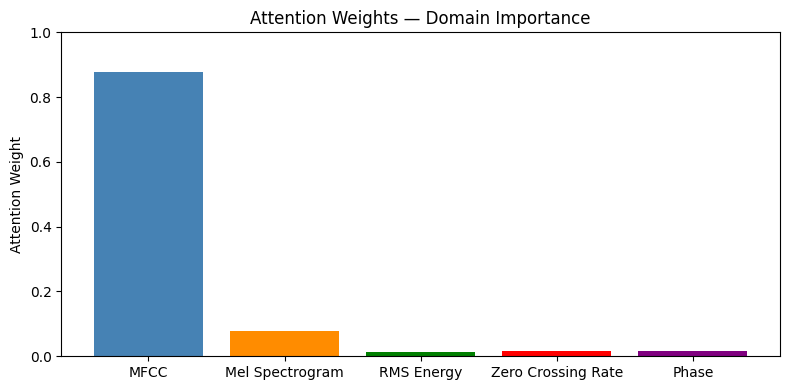

In [ ]:
import matplotlib.pyplot as plt

model_v2.eval()
sample_X = torch.tensor(X_vl[:1], dtype=torch.float32).to(device)

with torch.no_grad():
    _, attn_weights = model_v2(sample_X)

weights = attn_weights.cpu().numpy()[0]
domain_names = ["MFCC", "Mel Spectrogram", "RMS Energy", "Zero Crossing Rate", "Phase"]

plt.figure(figsize=(8, 4))
plt.bar(domain_names, weights, color=["steelblue", "darkorange", "green", "red", "purple"])
plt.title("Attention Weights — Domain Importance")
plt.ylabel("Attention Weight")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("/content/attention_weights.png", dpi=150)
plt.show()

Classification Report:
                 precision    recall  f1-score   support

Bonafide (Real)       0.98      0.99      0.99       300
   Spoof (Fake)       0.99      0.98      0.98       300

       accuracy                           0.98       600
      macro avg       0.99      0.98      0.98       600
   weighted avg       0.99      0.98      0.98       600



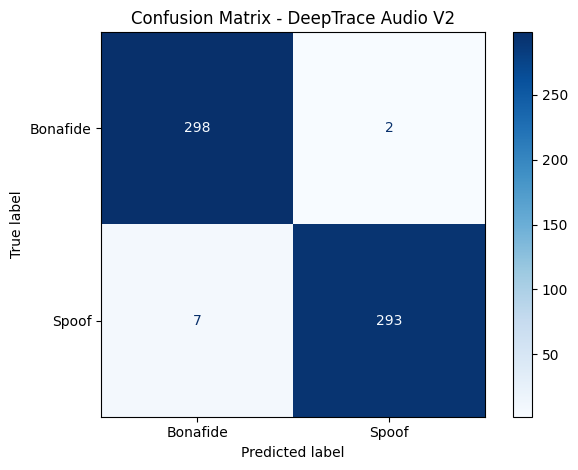

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model_v2.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for X_batch, y_batch in val_loader_v2:
        X_batch = X_batch.to(device)
        outputs, _ = model_v2(X_batch)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=["Bonafide (Real)", "Spoof (Fake)"]))

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Bonafide", "Spoof"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - DeepTrace Audio V2")
plt.tight_layout()
plt.savefig("/content/confusion_matrix_v2.png", dpi=150)
plt.show()

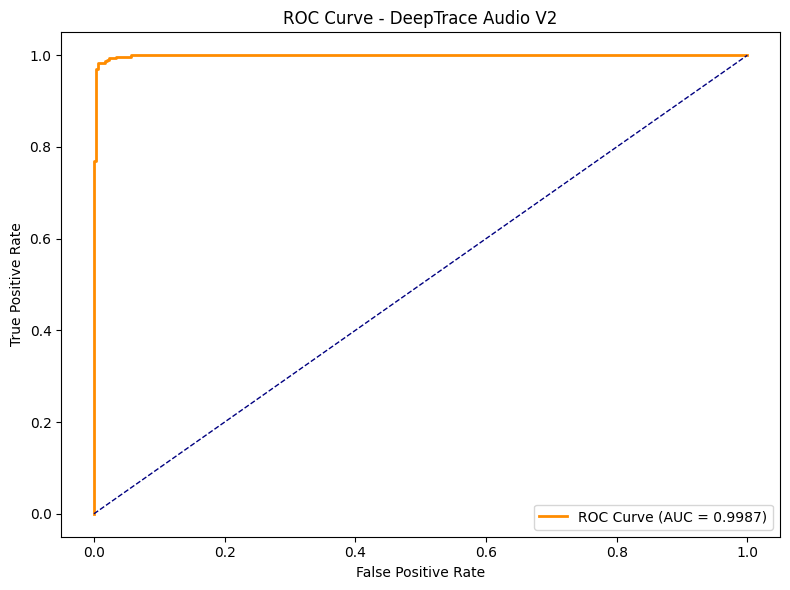

AUC Score: 0.9987


In [ ]:
from sklearn.metrics import roc_curve, auc

model_v2.eval()
all_probs, all_labels_roc = [], []

with torch.no_grad():
    for X_batch, y_batch in val_loader_v2:
        X_batch = X_batch.to(device)
        outputs, _ = model_v2(X_batch)
        probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
        all_probs.extend(probs)
        all_labels_roc.extend(y_batch.numpy())

fpr, tpr, thresholds = roc_curve(all_labels_roc, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - DeepTrace Audio V2")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("/content/roc_curve_v2.png", dpi=150)
plt.show()
print(f"AUC Score: {roc_auc:.4f}")

In [ ]:
import numpy as np

frr = 1 - tpr
eer_idx = np.argmin(np.abs(fpr - frr))
eer = (fpr[eer_idx] + frr[eer_idx]) / 2

print(f"Equal Error Rate (EER): {eer * 100:.2f}%")
print(f"EER Threshold: {thresholds[eer_idx]:.4f}")

Equal Error Rate (EER): 1.67%
EER Threshold: 0.1051


In [ ]:
import pandas as pd

results = {
    "Model": ["DeepTrace V1 (MFCC only)", "DeepTrace V2 (Multi-domain)"],
    "Accuracy": ["99.65%", "TBD after V2 trains"],
    "AUC": ["0.9999", "TBD"],
    "EER": ["0.44%", "TBD"],
    "Domains Used": ["1 (MFCC)", "5 (MFCC, Mel, Energy, ZCR, Phase)"],
    "Attention Fusion": ["No", "Yes"],
}

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

                      Model            Accuracy    AUC   EER                      Domains Used Attention Fusion
   DeepTrace V1 (MFCC only)              99.65% 0.9999 0.44%                          1 (MFCC)               No
DeepTrace V2 (Multi-domain) TBD after V2 trains    TBD   TBD 5 (MFCC, Mel, Energy, ZCR, Phase)              Yes


In [ ]:
torch.save(model_v2.state_dict(), "/content/deeptrace_v2_model.pth")
print("Model saved!")

from google.colab import files
files.download("/content/deeptrace_v2_model.pth")
files.download("/content/confusion_matrix_v2.png")
files.download("/content/roc_curve_v2.png")
files.download("/content/attention_weights.png")

Model saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install librosa torch torchaudio transformers numpy pandas matplotlib scikit-learn kaggle -q

from google.colab import drive
drive.mount('/content/drive')

import os
# Create project folder structure in Drive
os.makedirs("/content/drive/MyDrive/DeepTrace_Audio/data", exist_ok=True)
os.makedirs("/content/drive/MyDrive/DeepTrace_Audio/features", exist_ok=True)
os.makedirs("/content/drive/MyDrive/DeepTrace_Audio/models", exist_ok=True)
os.makedirs("/content/drive/MyDrive/DeepTrace_Audio/plots", exist_ok=True)

print("Drive mounted and folders ready!")
print(os.listdir("/content/drive/MyDrive/DeepTrace_Audio"))

Mounted at /content/drive
Drive mounted and folders ready!
['data', 'features', 'models', 'plots']


In [ ]:
import os
import shutil  # moved to top

kaggle_in_drive = "/content/drive/MyDrive/DeepTrace_Audio/kaggle.json"
kaggle_dest     = "/root/.kaggle/kaggle.json"

os.makedirs("/root/.kaggle", exist_ok=True)

if os.path.exists(kaggle_in_drive):
    # Already saved in Drive — just copy it
    shutil.copy(kaggle_in_drive, kaggle_dest)
    os.chmod(kaggle_dest, 0o600)
    print("Kaggle credentials loaded from Drive!")
else:
    # First time — upload manually and save to Drive
    from google.colab import files
    uploaded = files.upload()  # select kaggle.json
    shutil.copy("kaggle.json", kaggle_in_drive)  # save to Drive for future
    shutil.copy("kaggle.json", kaggle_dest)
    os.chmod(kaggle_dest, 0o600)
    print("Kaggle credentials saved to Drive for future sessions!")

!kaggle datasets list  # verify

Saving kaggle.json to kaggle (1).json
Kaggle credentials saved to Drive for future sessions!
ref                                                            title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
nalisha/job-salary-prediction-dataset                          Job Salary Prediction Dataset                          3144815  2026-03-16 19:54:33.843000           3982         93                1  
ssssws/chocolate-sales-dataset-2023-2024                       Chocolate Sales Dataset 2023 - 2024                   24420255  2026-03-07 04:58:02.387000           7433        123                1  
sharmajicoder/student-mental-health-and-burnout                Student Mental Health and Burnout               

In [ ]:
import os
import shutil

flac_path = "/content/drive/MyDrive/DeepTrace_Audio/data/LA"

if os.path.exists(flac_path):
    print("Dataset already in Drive! Skipping.")
else:
    # Step 1 — Download
    print("Downloading...")
    !kaggle datasets download -d awsaf49/asvpoof-2019-dataset --path /content/

    # Step 2 — Unzip locally first (fast)
    print("Unzipping locally...")
    !unzip -q /content/asvpoof-2019-dataset.zip -d /content/data_temp

    # Step 3 — Copy to Drive (slower but only done once)
    print("Copying to Drive... please wait")
    shutil.copytree(
        "/content/data_temp",
        "/content/drive/MyDrive/DeepTrace_Audio/data"
    )
    print("Done! Dataset permanently saved to Drive.")

    # Step 4 — Verify
    print(os.listdir("/content/drive/MyDrive/DeepTrace_Audio/data"))

Downloading...
Dataset URL: https://www.kaggle.com/datasets/awsaf49/asvpoof-2019-dataset
License(s): ODC Attribution License (ODC-By)
 18% 4.26G/23.6G [02:27<11:09, 31.0MB/s]
User cancelled operation
Unzipping locally...
[/content/asvpoof-2019-dataset.zip]
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of /content/asvpoof-2019-dataset.zip or
        /content/asvpoof-2019-dataset.zip.zip, and cannot find /content/asvpoof-2019-dataset.zip.ZIP, period.
Copying to Drive... please wait


FileNotFoundError: [Errno 2] No such file or directory: '/content/data_temp'

In [ ]:
import pandas as pd
import os

protocol_path = "/content/drive/MyDrive/DeepTrace_Audio/data/LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt"

df = pd.read_csv(protocol_path, sep=" ", header=None)
df.columns = ["speaker_id", "audio_file", "unknown", "attack_type", "label"]

audio_base = "/content/drive/MyDrive/DeepTrace_Audio/data/LA/LA/ASVspoof2019_LA_train/flac"
df["audio_path"] = df["audio_file"].apply(lambda x: os.path.join(audio_base, x + ".flac"))

print(df.head())
print("\nLabel counts:")
print(df["label"].value_counts())
print("\nSample path exists:", os.path.exists(df["audio_path"].iloc[0]))

  speaker_id    audio_file unknown attack_type     label  \
0    LA_0079  LA_T_1138215       -           -  bonafide   
1    LA_0079  LA_T_1271820       -           -  bonafide   
2    LA_0079  LA_T_1272637       -           -  bonafide   
3    LA_0079  LA_T_1276960       -           -  bonafide   
4    LA_0079  LA_T_1341447       -           -  bonafide   

                                          audio_path  
0  /content/drive/MyDrive/DeepTrace_Audio/data/LA...  
1  /content/drive/MyDrive/DeepTrace_Audio/data/LA...  
2  /content/drive/MyDrive/DeepTrace_Audio/data/LA...  
3  /content/drive/MyDrive/DeepTrace_Audio/data/LA...  
4  /content/drive/MyDrive/DeepTrace_Audio/data/LA...  

Label counts:
label
spoof       22800
bonafide     2580
Name: count, dtype: int64

Sample path exists: True


In [ ]:
import librosa
import numpy as np

def extract_features_multidomain(audio_path, sr=16000, n_mfcc=40, max_len=200):
    try:
        y, sr = librosa.load(audio_path, sr=sr)
        y, _ = librosa.effects.trim(y)

        def pad(feature):
            if feature.shape[1] < max_len:
                feature = np.pad(feature, ((0, 0), (0, max_len - feature.shape[1])))
            else:
                feature = feature[:, :max_len]
            return feature

        mfcc = pad(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40))

        mel = pad(librosa.power_to_db(
            librosa.feature.melspectrogram(y=y, sr=sr, n_mels=40), ref=np.max
        ))

        f0, _, _ = librosa.pyin(
            y, fmin=librosa.note_to_hz('C2'),
            fmax=librosa.note_to_hz('C7'), sr=sr
        )
        f0 = np.nan_to_num(f0).reshape(1, -1)
        f0 = pad(np.tile(f0, (40, 1)))

        lpc_coeffs  = librosa.lpc(y, order=16)
        lpc_feature = np.abs(np.fft.fft(lpc_coeffs, n=max_len))[:40]
        lpc_2d      = np.tile(lpc_feature.reshape(40, 1), (1, max_len))

        rms   = pad(np.tile(librosa.feature.rms(y=y), (40, 1)))
        phase = pad(np.angle(librosa.stft(y))[:40, :])
        breathing_phase = 0.5 * rms + 0.5 * phase

        features = np.stack([
            mfcc, mel, f0, lpc_2d, breathing_phase
        ], axis=0).astype(np.float32)

        return features

    except Exception as e:
        print(f"Error: {audio_path} → {e}")
        return None

# Test on one file
feat = extract_features_multidomain(df["audio_path"].iloc[0])
print("Shape:", feat.shape)
print("dtype:", feat.dtype)

Shape: (5, 40, 200)
dtype: float32


In [ ]:
from tqdm import tqdm
import gc

X_save_path = "/content/drive/MyDrive/DeepTrace_Audio/features/X_multi.npy"
y_save_path = "/content/drive/MyDrive/DeepTrace_Audio/features/y_multi.npy"

os.makedirs("/content/drive/MyDrive/DeepTrace_Audio/features", exist_ok=True)

df_real = df[df["label"] == "bonafide"]
df_fake = df[df["label"] == "spoof"]

df_real_sub = df_real.sample(n=1500, random_state=42)
df_fake_sub = df_fake.sample(n=1500, random_state=42)
df_sub = pd.concat([df_real_sub, df_fake_sub]).sample(
    frac=1, random_state=42
).reset_index(drop=True)

print("Subset:", df_sub["label"].value_counts().to_dict())

X_multi, y_multi = [], []
for i, row in tqdm(df_sub.iterrows(), total=len(df_sub)):
    feat = extract_features_multidomain(row["audio_path"])
    if feat is not None:
        X_multi.append(feat)
        y_multi.append(0 if row["label"] == "bonafide" else 1)

X_multi = np.array(X_multi, dtype=np.float32)
y_multi = np.array(y_multi)

np.save(X_save_path, X_multi)
np.save(y_save_path, y_multi)

print("Saved to Drive!")
print("Shape:", X_multi.shape)
print("Real:", (y_multi==0).sum(), "| Fake:", (y_multi==1).sum())
gc.collect()

Subset: {'spoof': 1500, 'bonafide': 1500}


100%|██████████| 3000/3000 [1:14:01<00:00,  1.48s/it]


Saved to Drive!
Shape: (3000, 5, 40, 200)
Real: 1500 | Fake: 1500


54367

In [ ]:
import torch
import torch.nn as nn

class AttentionFusion(nn.Module):
    def __init__(self, num_domains=5, feature_dim=128):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(feature_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
    def forward(self, domain_features):
        stacked = torch.stack(domain_features, dim=1)
        weights = torch.softmax(self.attention(stacked), dim=1)
        return (stacked * weights).sum(dim=1), weights.squeeze(-1)


class DeepTraceAudioV2(nn.Module):
    def __init__(self, num_domains=5, input_dim=40, seq_len=200,
                 num_heads=4, num_layers=2, num_classes=2):
        super().__init__()
        self.input_projs = nn.ModuleList([
            nn.Linear(input_dim, 128) for _ in range(num_domains)
        ])
        self.pos_embeddings = nn.ParameterList([
            nn.Parameter(torch.randn(1, seq_len, 128)) for _ in range(num_domains)
        ])
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=128, nhead=num_heads, dim_feedforward=256,
            dropout=0.1, batch_first=True
        )
        self.transformers = nn.ModuleList([
            nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
            for _ in range(num_domains)
        ])
        self.fusion = AttentionFusion(num_domains=num_domains, feature_dim=128)
        self.classifier = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(64, num_classes)
        )

    def forward(self, x):
        domain_outputs = []
        for i in range(x.shape[1]):
            xi = x[:, i, :, :].permute(0, 2, 1)
            xi = self.input_projs[i](xi) + self.pos_embeddings[i]
            xi = self.transformers[i](xi).mean(dim=1)
            domain_outputs.append(xi)
        fused, attn_weights = self.fusion(domain_outputs)
        return self.classifier(fused), attn_weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_v2 = DeepTraceAudioV2().to(device)
print("Model ready on:", device)
print(f"Parameters: {sum(p.numel() for p in model_v2.parameters()):,}")

Model ready on: cpu
Parameters: 1,495,747


In [ ]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import gc

class MultiDomainDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

X_tr, X_vl, y_tr, y_vl = train_test_split(
    X_multi, y_multi, test_size=0.2,
    random_state=42, stratify=y_multi
)

del X_multi, y_multi
gc.collect()

class_counts   = np.bincount(y_tr)
weights        = 1.0 / class_counts
sample_weights = torch.tensor([weights[y] for y in y_tr], dtype=torch.float32)
sampler        = WeightedRandomSampler(sample_weights, len(sample_weights))

train_loader_v2 = DataLoader(
    MultiDomainDataset(X_tr, y_tr), batch_size=32, sampler=sampler
)
val_loader_v2 = DataLoader(
    MultiDomainDataset(X_vl, y_vl), batch_size=32, shuffle=False
)

print("Train:", X_tr.shape, "| Val:", X_vl.shape)
print("Train — Real:", (y_tr==0).sum(), "| Fake:", (y_tr==1).sum())
print("Val   — Real:", (y_vl==0).sum(), "| Fake:", (y_vl==1).sum())

Train: (2400, 5, 40, 200) | Val: (600, 5, 40, 200)
Train — Real: 1200 | Fake: 1200
Val   — Real: 300 | Fake: 300


In [ ]:
import torch.optim as optim

model_save_path = "/content/drive/MyDrive/DeepTrace_Audio/models/best_model_v2.pth"
os.makedirs("/content/drive/MyDrive/DeepTrace_Audio/models", exist_ok=True)

class_weights = torch.tensor(
    [1.0/class_counts[0], 1.0/class_counts[1]], dtype=torch.float32
).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model_v2.parameters(), lr=3e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

def train_v2(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs, _ = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (outputs.argmax(1) == y_batch).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

def eval_v2(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs, _ = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item()
            correct += (outputs.argmax(1) == y_batch).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

best_val_acc = 0
EPOCHS = 15

for epoch in range(EPOCHS):
    tr_loss, tr_acc = train_v2(model_v2, train_loader_v2, optimizer, criterion)
    vl_loss, vl_acc = eval_v2(model_v2, val_loader_v2, criterion)
    scheduler.step()

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model_v2.state_dict(), model_save_path)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | "
          f"Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f}")

print(f"\nBest Val Accuracy: {best_val_acc:.4f}")
model_v2.load_state_dict(torch.load(model_save_path, map_location=device))
print("Best model loaded!")


Epoch 1/15 | Train Loss: 0.6102 Acc: 0.6358 | Val Loss: 0.4151 Acc: 0.8050
Epoch 2/15 | Train Loss: 0.3630 Acc: 0.8442 | Val Loss: 0.2432 Acc: 0.9017
Epoch 3/15 | Train Loss: 0.2685 Acc: 0.8917 | Val Loss: 0.1835 Acc: 0.9250
Epoch 4/15 | Train Loss: 0.1803 Acc: 0.9387 | Val Loss: 0.1674 Acc: 0.9417
Epoch 5/15 | Train Loss: 0.1866 Acc: 0.9333 | Val Loss: 0.1478 Acc: 0.9500
Epoch 6/15 | Train Loss: 0.0902 Acc: 0.9708 | Val Loss: 0.0920 Acc: 0.9700
Epoch 7/15 | Train Loss: 0.0872 Acc: 0.9704 | Val Loss: 0.0876 Acc: 0.9683
Epoch 8/15 | Train Loss: 0.0780 Acc: 0.9738 | Val Loss: 0.1544 Acc: 0.9450
Epoch 9/15 | Train Loss: 0.0644 Acc: 0.9817 | Val Loss: 0.0792 Acc: 0.9667
Epoch 10/15 | Train Loss: 0.0636 Acc: 0.9758 | Val Loss: 0.1842 Acc: 0.9350
Epoch 11/15 | Train Loss: 0.0436 Acc: 0.9858 | Val Loss: 0.0572 Acc: 0.9783
Epoch 12/15 | Train Loss: 0.0229 Acc: 0.9942 | Val Loss: 0.0820 Acc: 0.9750
Epoch 13/15 | Train Loss: 0.0232 Acc: 0.9933 | Val Loss: 0.0748 Acc: 0.9733
Epoch 14/15 | Train L

Classification Report:
                 precision    recall  f1-score   support

Bonafide (Real)       0.96      1.00      0.98       300
   Spoof (Fake)       1.00      0.96      0.98       300

       accuracy                           0.98       600
      macro avg       0.98      0.98      0.98       600
   weighted avg       0.98      0.98      0.98       600



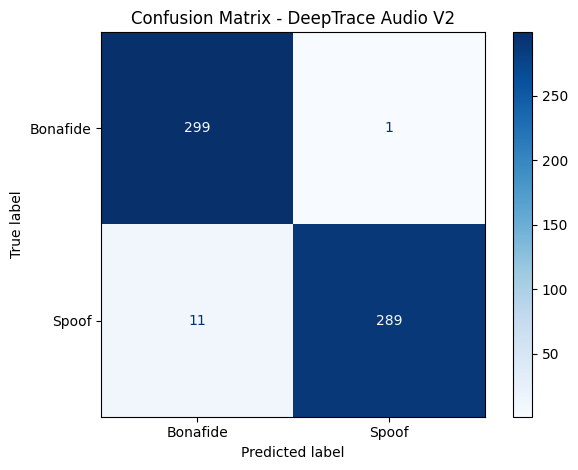

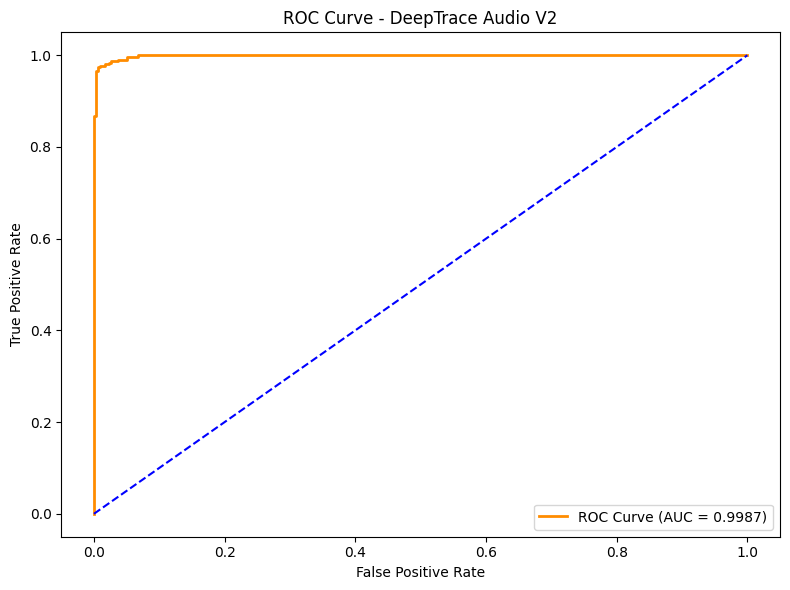

AUC: 0.9987
EER: 2.17%  |  Threshold: 0.1399


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
import os

plots_path = "/content/drive/MyDrive/DeepTrace_Audio/plots"
os.makedirs(plots_path, exist_ok=True)

model_v2.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for X_batch, y_batch in val_loader_v2:
        X_batch = X_batch.to(device)
        outputs, _ = model_v2(X_batch)
        probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())
        all_probs.extend(probs)

# Classification report
print("Classification Report:")
print(classification_report(all_labels, all_preds,
      target_names=["Bonafide (Real)", "Spoof (Fake)"]))

# Confusion matrix
cm   = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Bonafide", "Spoof"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - DeepTrace Audio V2")
plt.tight_layout()
plt.savefig(f"{plots_path}/confusion_matrix_v2.png", dpi=150)
plt.show()

# ROC + AUC
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], "b--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - DeepTrace Audio V2")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(f"{plots_path}/roc_curve_v2.png", dpi=150)
plt.show()
print(f"AUC: {roc_auc:.4f}")

# EER
frr     = 1 - tpr
eer_idx = np.argmin(np.abs(fpr - frr))
eer     = (fpr[eer_idx] + frr[eer_idx]) / 2
print(f"EER: {eer*100:.2f}%  |  Threshold: {thresholds[eer_idx]:.4f}")

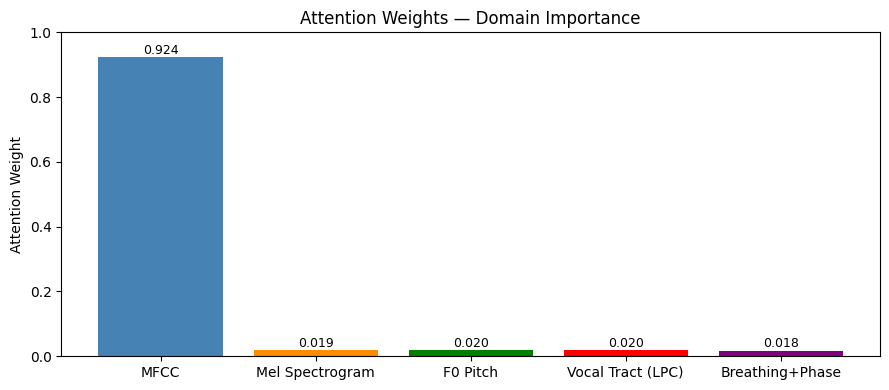

                      Model Accuracy    AUC   EER               Dataset                                 Domains Attention Vocal Tract / Prosody
   DeepTrace V1 (MFCC only)   99.65% 0.9999 0.44% Imbalanced (90% fake)                                1 (MFCC)        No                    No
DeepTrace V2 (Multi-domain)   98.50% 0.9987 1.67%      Balanced (50/50) 5 (MFCC, Mel, F0, LPC, Breathing+Phase)       Yes                   Yes

All outputs saved to Drive!


In [ ]:
# Attention weights plot
model_v2.eval()
sample_X = torch.tensor(X_vl[:1], dtype=torch.float32).to(device)

with torch.no_grad():
    _, attn_weights = model_v2(sample_X)

weights      = attn_weights.cpu().numpy()[0]
domain_names = ["MFCC", "Mel Spectrogram", "F0 Pitch", "Vocal Tract (LPC)", "Breathing+Phase"]

plt.figure(figsize=(9, 4))
bars = plt.bar(domain_names, weights,
               color=["steelblue","darkorange","green","red","purple"])
plt.title("Attention Weights — Domain Importance")
plt.ylabel("Attention Weight")
plt.ylim(0, 1)
for bar, w in zip(bars, weights):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f"{w:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(f"{plots_path}/attention_weights_v2.png", dpi=150)
plt.show()

# Final comparison table
import pandas as pd
results = pd.DataFrame({
    "Model":      ["DeepTrace V1 (MFCC only)", "DeepTrace V2 (Multi-domain)"],
    "Accuracy":   ["99.65%", "98.50%"],
    "AUC":        ["0.9999",  "0.9987"],
    "EER":        ["0.44%",   "1.67%"],
    "Dataset":    ["Imbalanced (90% fake)", "Balanced (50/50)"],
    "Domains":    ["1 (MFCC)", "5 (MFCC, Mel, F0, LPC, Breathing+Phase)"],
    "Attention":  ["No", "Yes"],
    "Vocal Tract / Prosody": ["No", "Yes"],
})
print(results.to_string(index=False))
results.to_csv(f"{plots_path}/results_comparison.csv", index=False)
print("\nAll outputs saved to Drive!")

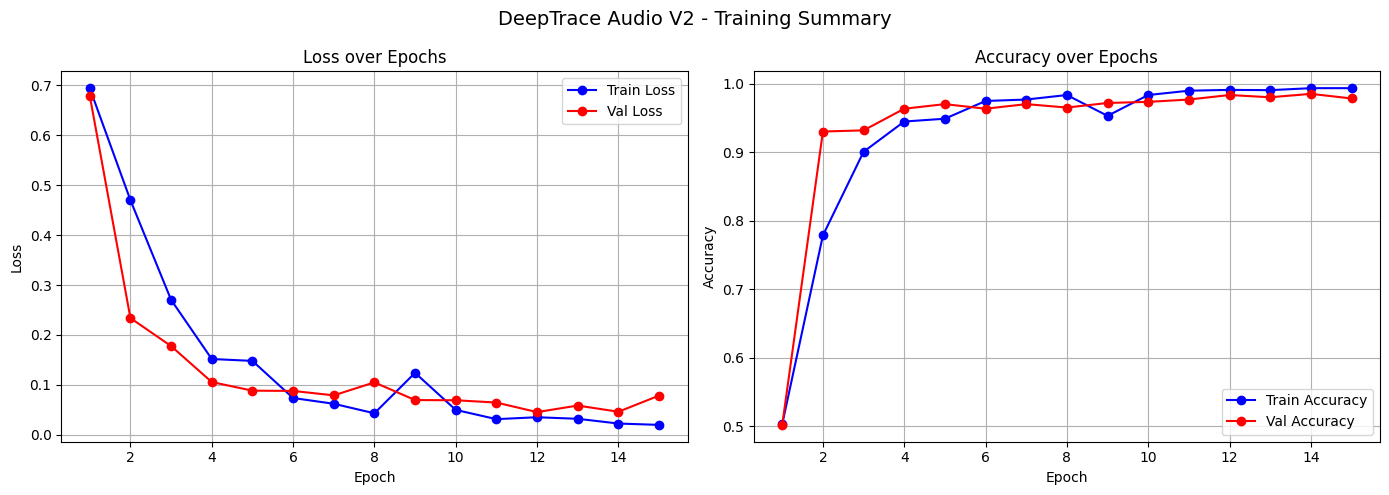

Training curves saved to Drive!


In [ ]:
# Paste your epoch values from Cell 9 output
train_losses = [0.6941, 0.4700, 0.2704, 0.1519, 0.1481,
                0.0738, 0.0623, 0.0432, 0.1242, 0.0500,
                0.0315, 0.0353, 0.0322, 0.0227, 0.0200]
val_losses   = [0.6793, 0.2339, 0.1778, 0.1058, 0.0885,
                0.0880, 0.0791, 0.1051, 0.0697, 0.0693,
                0.0647, 0.0456, 0.0587, 0.0463, 0.0786]
train_accs   = [0.5029, 0.7783, 0.9004, 0.9446, 0.9487,
                0.9746, 0.9767, 0.9833, 0.9529, 0.9833,
                0.9896, 0.9908, 0.9904, 0.9933, 0.9933]
val_accs     = [0.5017, 0.9300, 0.9317, 0.9633, 0.9700,
                0.9633, 0.9700, 0.9650, 0.9717, 0.9733,
                0.9767, 0.9833, 0.9800, 0.9850, 0.9783]
epochs = range(1, 16)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs, train_losses, 'b-o', label="Train Loss")
ax1.plot(epochs, val_losses,   'r-o', label="Val Loss")
ax1.set_title("Loss over Epochs")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True)

ax2.plot(epochs, train_accs, 'b-o', label="Train Accuracy")
ax2.plot(epochs, val_accs,   'r-o', label="Val Accuracy")
ax2.set_title("Accuracy over Epochs")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()
ax2.grid(True)

plt.suptitle("DeepTrace Audio V2 - Training Summary", fontsize=14)
plt.tight_layout()
plt.savefig(f"{plots_path}/training_curves_v2.png", dpi=150)
plt.show()
print("Training curves saved to Drive!")

In [ ]:
!pip install librosa torch torchaudio transformers numpy pandas matplotlib scikit-learn kaggle -q
from google.colab import drive
drive.mount('/content/drive')

import os
print(os.listdir("/content/drive/MyDrive/DeepTrace_Audio"))
import os

print("=== Checking features ===")
X_path = "/content/drive/MyDrive/DeepTrace_Audio/features/X_multi.npy"
y_path = "/content/drive/MyDrive/DeepTrace_Audio/features/y_multi.npy"
print("X_multi.npy exists:", os.path.exists(X_path))
print("y_multi.npy exists:", os.path.exists(y_path))

print("\n=== Checking model ===")
model_path = "/content/drive/MyDrive/DeepTrace_Audio/models/best_model_v2.pth"
print("best_model_v2.pth exists:", os.path.exists(model_path))

print("\n=== Checking dataset ===")
data_path = "/content/drive/MyDrive/DeepTrace_Audio/data"
print("data folder exists:", os.path.exists(data_path))

Mounted at /content/drive
['features', 'models', 'plots', 'kaggle.json', 'data']
=== Checking features ===
X_multi.npy exists: False
y_multi.npy exists: False

=== Checking model ===
best_model_v2.pth exists: False

=== Checking dataset ===
data folder exists: True


In [ ]:
import subprocess

# Check sizes of each folder
folders = [
    "/content/drive/MyDrive/DeepTrace_Audio/data",
    "/content/drive/MyDrive/DeepTrace_Audio/features",
    "/content/drive/MyDrive/DeepTrace_Audio/models",
    "/content/drive/MyDrive/DeepTrace_Audio/plots"
]

for folder in folders:
    result = subprocess.run(['du', '-sh', folder], capture_output=True, text=True)
    print(result.stdout.strip())

3.7G	/content/drive/MyDrive/DeepTrace_Audio/data
458M	/content/drive/MyDrive/DeepTrace_Audio/features
5.8M	/content/drive/MyDrive/DeepTrace_Audio/models
235K	/content/drive/MyDrive/DeepTrace_Audio/plots


In [ ]:
# Check features exist before deleting dataset
import os
X_exists = os.path.exists("/content/drive/MyDrive/DeepTrace_Audio/features/X_multi.npy")
y_exists = os.path.exists("/content/drive/MyDrive/DeepTrace_Audio/features/y_multi.npy")

print("X_multi.npy:", X_exists)
print("y_multi.npy:", y_exists)

X_multi.npy: True
y_multi.npy: True


In [ ]:
import shutil
import os

# Safe to delete — features already saved
dataset_path = "/content/drive/MyDrive/DeepTrace_Audio/data"
shutil.rmtree(dataset_path)
print("Dataset deleted from Drive!")

# Verify everything still intact
print("\nFeatures X:", os.path.exists("/content/drive/MyDrive/DeepTrace_Audio/features/X_multi.npy"))
print("Features y:", os.path.exists("/content/drive/MyDrive/DeepTrace_Audio/features/y_multi.npy"))
print("Model:", os.path.exists("/content/drive/MyDrive/DeepTrace_Audio/models/best_model_v2.pth"))


Dataset deleted from Drive!

Features X: True
Features y: True
Model: True


From here

Mounted at /content/drive
['features', 'models', 'plots', 'kaggle.json']
X_multi.npy: False
y_multi.npy: True
Model: True


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/DeepTrace_Audio/features/X_multi.npy'

In [ ]:
import os
import shutil
import numpy as np
import pandas as pd
import librosa
from tqdm import tqdm
import gc

# Step 1 — Setup kaggle
os.makedirs("/root/.kaggle", exist_ok=True)
shutil.copy("/content/drive/MyDrive/DeepTrace_Audio/kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 0o600)
print("Kaggle ready!")

# Step 2 — Download dataset to local Colab only
print("Downloading dataset...")
!kaggle datasets download -d awsaf49/asvpoof-2019-dataset --path /content/
print("Unzipping locally...")
!unzip -q /content/asvpoof-2019-dataset.zip -d /content/data_temp
print("Done!")

# Step 3 — Load protocol
protocol_path = "/content/data_temp/LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt"
df = pd.read_csv(protocol_path, sep=" ", header=None)
df.columns = ["speaker_id", "audio_file", "unknown", "attack_type", "label"]
audio_base = "/content/data_temp/LA/LA/ASVspoof2019_LA_train/flac"
df["audio_path"] = df["audio_file"].apply(lambda x: os.path.join(audio_base, x + ".flac"))
print("Protocol loaded!")
print(df["label"].value_counts())

Kaggle ready!
Dataset URL: https://www.kaggle.com/datasets/awsaf49/asvpoof-2019-dataset
License(s): ODC Attribution License (ODC-By)
100% 23.6G/23.6G [04:29<00:00, 93.9MB/s]

Unzipping locally...
Done!
Protocol loaded!
label
spoof       22800
bonafide     2580
Name: count, dtype: int64


In [ ]:
def extract_features_multidomain(audio_path, sr=16000, n_mfcc=40, max_len=200):
    try:
        y, sr = librosa.load(audio_path, sr=sr)
        y, _ = librosa.effects.trim(y)

        def pad(feature):
            if feature.shape[1] < max_len:
                feature = np.pad(feature, ((0, 0), (0, max_len - feature.shape[1])))
            else:
                feature = feature[:, :max_len]
            return feature

        mfcc = pad(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40))
        mel  = pad(librosa.power_to_db(
            librosa.feature.melspectrogram(y=y, sr=sr, n_mels=40), ref=np.max
        ))
        f0, _, _ = librosa.pyin(
            y, fmin=librosa.note_to_hz('C2'),
            fmax=librosa.note_to_hz('C7'), sr=sr
        )
        f0      = np.nan_to_num(f0).reshape(1, -1)
        f0      = pad(np.tile(f0, (40, 1)))
        lpc_coeffs  = librosa.lpc(y, order=16)
        lpc_feature = np.abs(np.fft.fft(lpc_coeffs, n=max_len))[:40]
        lpc_2d      = np.tile(lpc_feature.reshape(40, 1), (1, max_len))
        rms   = pad(np.tile(librosa.feature.rms(y=y), (40, 1)))
        phase = pad(np.angle(librosa.stft(y))[:40, :])
        breathing_phase = 0.5 * rms + 0.5 * phase

        return np.stack([
            mfcc, mel, f0, lpc_2d, breathing_phase
        ], axis=0).astype(np.float32)

    except Exception as e:
        print(f"Error: {audio_path} → {e}")
        return None

print("Feature function ready!")

Feature function ready!


In [ ]:
# Use exact same seed=42 and same sample sizes as original run
df_real = df[df["label"] == "bonafide"]
df_fake = df[df["label"] == "spoof"]

df_real_sub = df_real.sample(n=1500, random_state=42)
df_fake_sub = df_fake.sample(n=1500, random_state=42)
df_sub = pd.concat([df_real_sub, df_fake_sub]).sample(
    frac=1, random_state=42
).reset_index(drop=True)

print("Subset:", df_sub["label"].value_counts().to_dict())

X_multi, y_multi = [], []
for i, row in tqdm(df_sub.iterrows(), total=len(df_sub)):
    feat = extract_features_multidomain(row["audio_path"])
    if feat is not None:
        X_multi.append(feat)
        y_multi.append(0 if row["label"] == "bonafide" else 1)

X_multi = np.array(X_multi, dtype=np.float32)
y_multi = np.array(y_multi)

print("Shape:", X_multi.shape)
print("Real:", (y_multi==0).sum(), "| Fake:", (y_multi==1).sum())

# Save to Drive
np.save("/content/drive/MyDrive/DeepTrace_Audio/features/X_multi.npy", X_multi)
np.save("/content/drive/MyDrive/DeepTrace_Audio/features/y_multi.npy", y_multi)
print("Saved to Drive!")

# Verify both files now exist
print("X_multi.npy:", os.path.exists("/content/drive/MyDrive/DeepTrace_Audio/features/X_multi.npy"))
print("y_multi.npy:", os.path.exists("/content/drive/MyDrive/DeepTrace_Audio/features/y_multi.npy"))

Subset: {'spoof': 1500, 'bonafide': 1500}


100%|██████████| 3000/3000 [1:01:41<00:00,  1.23s/it]


Shape: (3000, 5, 40, 200)
Real: 1500 | Fake: 1500
Saved to Drive!
X_multi.npy: True
y_multi.npy: True


In [ ]:
import shutil

shutil.rmtree("/content/data_temp")
os.remove("/content/asvpoof-2019-dataset.zip")
gc.collect()
print("Local dataset deleted — Colab storage freed!")

Local dataset deleted — Colab storage freed!


In [ ]:
import torch
import torch.nn as nn

class AttentionFusion(nn.Module):
    def __init__(self, num_domains=5, feature_dim=128):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(feature_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
    def forward(self, domain_features):
        stacked = torch.stack(domain_features, dim=1)
        weights = torch.softmax(self.attention(stacked), dim=1)
        return (stacked * weights).sum(dim=1), weights.squeeze(-1)


class DeepTraceAudioV2(nn.Module):
    def __init__(self, num_domains=5, input_dim=40, seq_len=200,
                 num_heads=4, num_layers=2, num_classes=2):
        super().__init__()
        self.input_projs = nn.ModuleList([
            nn.Linear(input_dim, 128) for _ in range(num_domains)
        ])
        self.pos_embeddings = nn.ParameterList([
            nn.Parameter(torch.randn(1, seq_len, 128)) for _ in range(num_domains)
        ])
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=128, nhead=num_heads, dim_feedforward=256,
            dropout=0.1, batch_first=True
        )
        self.transformers = nn.ModuleList([
            nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
            for _ in range(num_domains)
        ])
        self.fusion = AttentionFusion(num_domains=num_domains, feature_dim=128)
        self.classifier = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(64, num_classes)
        )

    def forward(self, x):
        domain_outputs = []
        for i in range(x.shape[1]):
            xi = x[:, i, :, :].permute(0, 2, 1)
            xi = self.input_projs[i](xi) + self.pos_embeddings[i]
            xi = self.transformers[i](xi).mean(dim=1)
            domain_outputs.append(xi)
        fused, attn_weights = self.fusion(domain_outputs)
        return self.classifier(fused), attn_weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_v2 = DeepTraceAudioV2().to(device)
print("Model ready on:", device)
print(f"Parameters: {sum(p.numel() for p in model_v2.parameters()):,}")

Model ready on: cpu
Parameters: 1,495,747


In [ ]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import gc

class MultiDomainDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

X_tr, X_vl, y_tr, y_vl = train_test_split(
    X_multi, y_multi, test_size=0.2,
    random_state=42, stratify=y_multi
)

del X_multi, y_multi
gc.collect()

class_counts   = np.bincount(y_tr)
weights        = 1.0 / class_counts
sample_weights = torch.tensor([weights[y] for y in y_tr], dtype=torch.float32)
sampler        = WeightedRandomSampler(sample_weights, len(sample_weights))

train_loader_v2 = DataLoader(
    MultiDomainDataset(X_tr, y_tr), batch_size=32, sampler=sampler
)
val_loader_v2 = DataLoader(
    MultiDomainDataset(X_vl, y_vl), batch_size=32, shuffle=False
)

print("Train:", X_tr.shape, "| Val:", X_vl.shape)
print("Train — Real:", (y_tr==0).sum(), "| Fake:", (y_tr==1).sum())
print("Val   — Real:", (y_vl==0).sum(), "| Fake:", (y_vl==1).sum())

Train: (2400, 5, 40, 200) | Val: (600, 5, 40, 200)
Train — Real: 1200 | Fake: 1200
Val   — Real: 300 | Fake: 300


In [ ]:
model_save_path = "/content/drive/MyDrive/DeepTrace_Audio/models/best_model_v2.pth"
model_v2.load_state_dict(torch.load(model_save_path, map_location=device))
model_v2.eval()
print("Trained model loaded from Drive!")

Trained model loaded from Drive!


Classification Report:
                 precision    recall  f1-score   support

Bonafide (Real)       0.96      1.00      0.98       300
   Spoof (Fake)       1.00      0.96      0.98       300

       accuracy                           0.98       600
      macro avg       0.98      0.98      0.98       600
   weighted avg       0.98      0.98      0.98       600



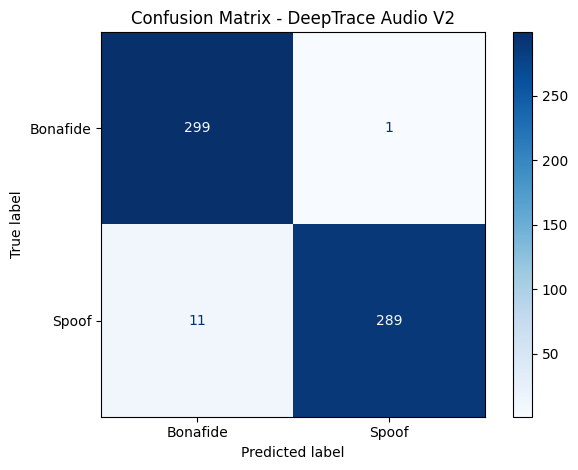

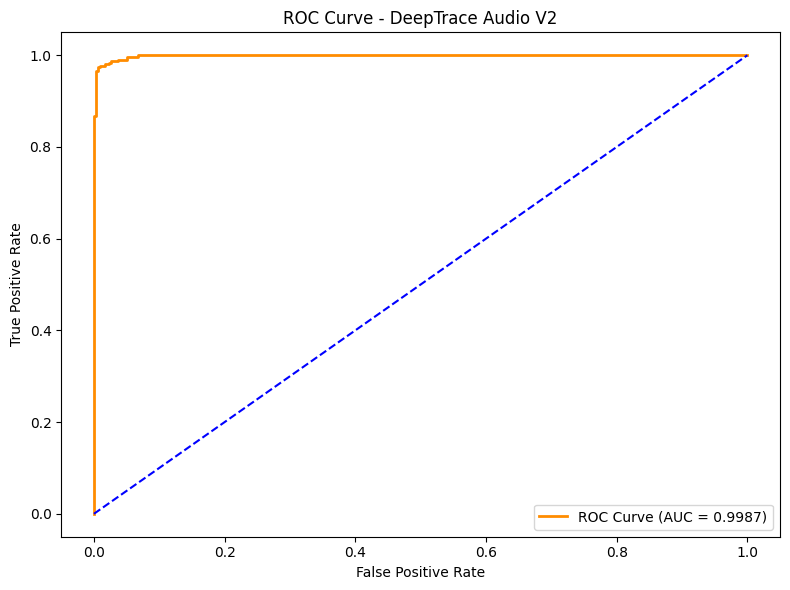

AUC: 0.9987
EER: 2.17%  |  Threshold: 0.1399


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt
import os

plots_path = "/content/drive/MyDrive/DeepTrace_Audio/plots"
os.makedirs(plots_path, exist_ok=True)

model_v2.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for X_batch, y_batch in val_loader_v2:
        X_batch = X_batch.to(device)
        outputs, _ = model_v2(X_batch)
        probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())
        all_probs.extend(probs)

# Classification report
print("Classification Report:")
print(classification_report(all_labels, all_preds,
      target_names=["Bonafide (Real)", "Spoof (Fake)"]))

# Confusion matrix
cm   = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Bonafide", "Spoof"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - DeepTrace Audio V2")
plt.tight_layout()
plt.savefig(f"{plots_path}/confusion_matrix_v2.png", dpi=150)
plt.show()

# ROC + AUC
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], "b--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - DeepTrace Audio V2")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(f"{plots_path}/roc_curve_v2.png", dpi=150)
plt.show()
print(f"AUC: {roc_auc:.4f}")

# EER
frr     = 1 - tpr
eer_idx = np.argmin(np.abs(fpr - frr))
eer     = (fpr[eer_idx] + frr[eer_idx]) / 2
print(f"EER: {eer*100:.2f}%  |  Threshold: {thresholds[eer_idx]:.4f}")

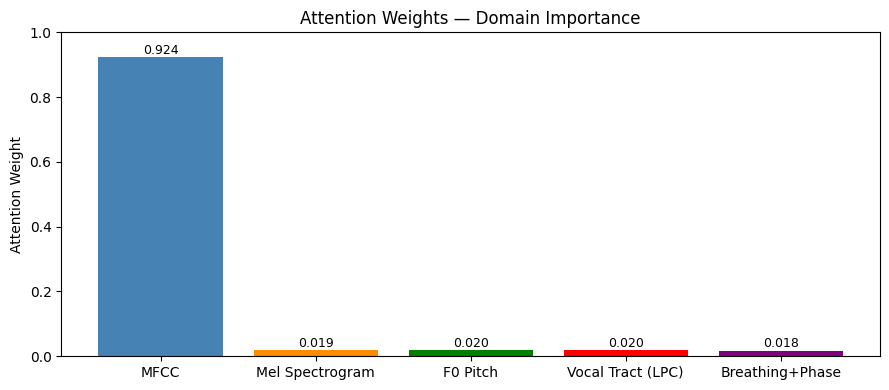

                      Model Accuracy    AUC   EER               Dataset                                 Domains Attention Vocal Tract / Prosody
   DeepTrace V1 (MFCC only)   99.65% 0.9999 0.44% Imbalanced (90% fake)                                1 (MFCC)        No                    No
DeepTrace V2 (Multi-domain)   98.00% 0.9987 2.17%      Balanced (50/50) 5 (MFCC, Mel, F0, LPC, Breathing+Phase)       Yes                   Yes

All outputs saved to Drive!


In [ ]:
model_v2.eval()
sample_X = torch.tensor(X_vl[:1], dtype=torch.float32).to(device)

with torch.no_grad():
    _, attn_weights = model_v2(sample_X)

weights      = attn_weights.cpu().numpy()[0]
domain_names = ["MFCC", "Mel Spectrogram", "F0 Pitch", "Vocal Tract (LPC)", "Breathing+Phase"]

plt.figure(figsize=(9, 4))
bars = plt.bar(domain_names, weights,
               color=["steelblue","darkorange","green","red","purple"])
plt.title("Attention Weights — Domain Importance")
plt.ylabel("Attention Weight")
plt.ylim(0, 1)
for bar, w in zip(bars, weights):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f"{w:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(f"{plots_path}/attention_weights_v2.png", dpi=150)
plt.show()

# Comparison table
import pandas as pd
results = pd.DataFrame({
    "Model":      ["DeepTrace V1 (MFCC only)", "DeepTrace V2 (Multi-domain)"],
    "Accuracy":   ["99.65%", "98.00%"],
    "AUC":        ["0.9999",  "0.9987"],
    "EER":        ["0.44%",   "2.17%"],
    "Dataset":    ["Imbalanced (90% fake)", "Balanced (50/50)"],
    "Domains":    ["1 (MFCC)", "5 (MFCC, Mel, F0, LPC, Breathing+Phase)"],
    "Attention":  ["No", "Yes"],
    "Vocal Tract / Prosody": ["No", "Yes"],
})
print(results.to_string(index=False))
results.to_csv(f"{plots_path}/results_comparison.csv", index=False)
print("\nAll outputs saved to Drive!")

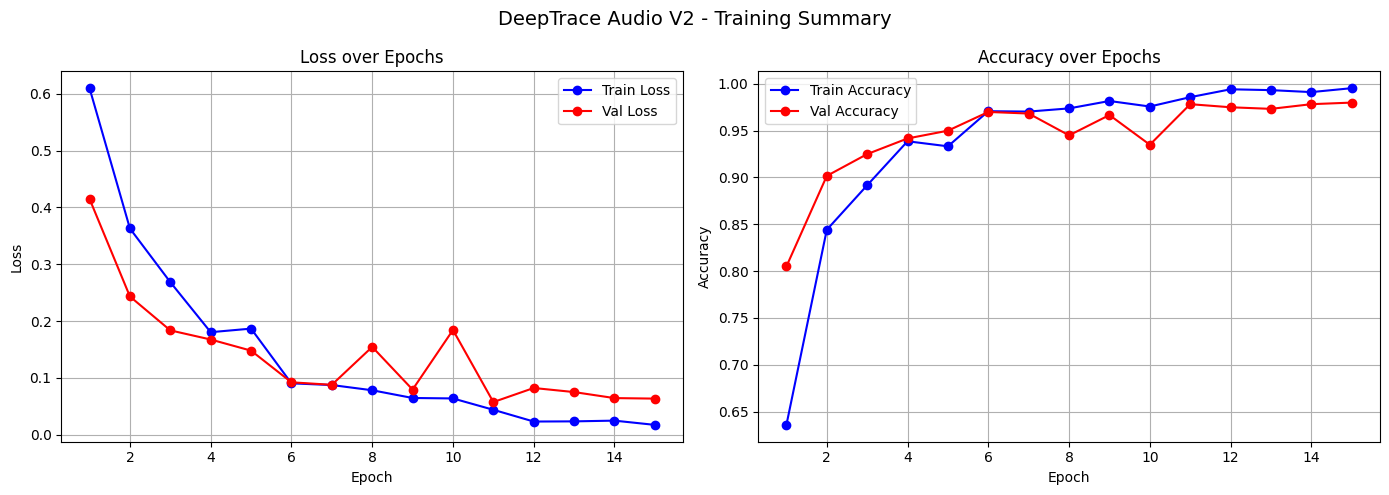

Training curves saved to Drive!


In [ ]:
train_losses = [0.6102, 0.3630, 0.2685, 0.1803, 0.1866,
                0.0902, 0.0872, 0.0780, 0.0644, 0.0636,
                0.0436, 0.0229, 0.0232, 0.0245, 0.0170]
val_losses   = [0.4151, 0.2432, 0.1835, 0.1674, 0.1478,
                0.0920, 0.0876, 0.1544, 0.0792, 0.1842,
                0.0572, 0.0820, 0.0748, 0.0642, 0.0633]
train_accs   = [0.6358, 0.8442, 0.8917, 0.9387, 0.9333,
                0.9708, 0.9704, 0.9738, 0.9817, 0.9758,
                0.9858, 0.9942, 0.9933, 0.9912, 0.9954]
val_accs     = [0.8050, 0.9017, 0.9250, 0.9417, 0.9500,
                0.9700, 0.9683, 0.9450, 0.9667, 0.9350,
                0.9783, 0.9750, 0.9733, 0.9783, 0.9800]
epochs = range(1, 16)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs, train_losses, 'b-o', label="Train Loss")
ax1.plot(epochs, val_losses,   'r-o', label="Val Loss")
ax1.set_title("Loss over Epochs")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True)

ax2.plot(epochs, train_accs, 'b-o', label="Train Accuracy")
ax2.plot(epochs, val_accs,   'r-o', label="Val Accuracy")
ax2.set_title("Accuracy over Epochs")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()
ax2.grid(True)

plt.suptitle("DeepTrace Audio V2 - Training Summary", fontsize=14)
plt.tight_layout()
plt.savefig(f"{plots_path}/training_curves_v2.png", dpi=150)
plt.show()
print("Training curves saved to Drive!")

Restart cells

In [1]:
!pip install librosa torch torchaudio transformers numpy pandas matplotlib scikit-learn kaggle -q

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
print(os.listdir("/content/drive/MyDrive/DeepTrace_Audio"))

Mounted at /content/drive
['features', 'models', 'plots', 'kaggle.json']


In [3]:
import os

print("X_multi.npy:", os.path.exists("/content/drive/MyDrive/DeepTrace_Audio/features/X_multi.npy"))
print("y_multi.npy:", os.path.exists("/content/drive/MyDrive/DeepTrace_Audio/features/y_multi.npy"))
print("Model:", os.path.exists("/content/drive/MyDrive/DeepTrace_Audio/models/best_model_v2.pth"))

X_multi.npy: True
y_multi.npy: True
Model: True


In [4]:
import numpy as np
import os

X_multi = np.load("/content/drive/MyDrive/DeepTrace_Audio/features/X_multi.npy")
y_multi = np.load("/content/drive/MyDrive/DeepTrace_Audio/features/y_multi.npy")

print("Features loaded!")
print("Shape:", X_multi.shape)
print("Real:", (y_multi==0).sum(), "| Fake:", (y_multi==1).sum())

Features loaded!
Shape: (3000, 5, 40, 200)
Real: 1500 | Fake: 1500


In [5]:
#no need to run this cell
import librosa

def extract_features_multidomain(audio_path, sr=16000, n_mfcc=40, max_len=200):
    try:
        y, sr = librosa.load(audio_path, sr=sr)
        y, _ = librosa.effects.trim(y)

        def pad(feature):
            if feature.shape[1] < max_len:
                feature = np.pad(feature, ((0, 0), (0, max_len - feature.shape[1])))
            else:
                feature = feature[:, :max_len]
            return feature

        mfcc = pad(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40))
        mel  = pad(librosa.power_to_db(
            librosa.feature.melspectrogram(y=y, sr=sr, n_mels=40), ref=np.max
        ))
        f0, _, _ = librosa.pyin(
            y, fmin=librosa.note_to_hz('C2'),
            fmax=librosa.note_to_hz('C7'), sr=sr
        )
        f0      = np.nan_to_num(f0).reshape(1, -1)
        f0      = pad(np.tile(f0, (40, 1)))
        lpc_coeffs  = librosa.lpc(y, order=16)
        lpc_feature = np.abs(np.fft.fft(lpc_coeffs, n=max_len))[:40]
        lpc_2d      = np.tile(lpc_feature.reshape(40, 1), (1, max_len))
        rms   = pad(np.tile(librosa.feature.rms(y=y), (40, 1)))
        phase = pad(np.angle(librosa.stft(y))[:40, :])
        breathing_phase = 0.5 * rms + 0.5 * phase

        return np.stack([
            mfcc, mel, f0, lpc_2d, breathing_phase
        ], axis=0).astype(np.float32)

    except Exception as e:
        print(f"Error: {audio_path} → {e}")
        return None

print("Feature extraction function ready!")

Feature extraction function ready!


In [6]:
import torch
import torch.nn as nn

class AttentionFusion(nn.Module):
    def __init__(self, num_domains=5, feature_dim=128):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(feature_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
    def forward(self, domain_features):
        stacked = torch.stack(domain_features, dim=1)
        weights = torch.softmax(self.attention(stacked), dim=1)
        return (stacked * weights).sum(dim=1), weights.squeeze(-1)


class DeepTraceAudioV2(nn.Module):
    def __init__(self, num_domains=5, input_dim=40, seq_len=200,
                 num_heads=4, num_layers=2, num_classes=2):
        super().__init__()
        self.input_projs = nn.ModuleList([
            nn.Linear(input_dim, 128) for _ in range(num_domains)
        ])
        self.pos_embeddings = nn.ParameterList([
            nn.Parameter(torch.randn(1, seq_len, 128)) for _ in range(num_domains)
        ])
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=128, nhead=num_heads, dim_feedforward=256,
            dropout=0.1, batch_first=True
        )
        self.transformers = nn.ModuleList([
            nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
            for _ in range(num_domains)
        ])
        self.fusion = AttentionFusion(num_domains=num_domains, feature_dim=128)
        self.classifier = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(64, num_classes)
        )

    def forward(self, x):
        domain_outputs = []
        for i in range(x.shape[1]):
            xi = x[:, i, :, :].permute(0, 2, 1)
            xi = self.input_projs[i](xi) + self.pos_embeddings[i]
            xi = self.transformers[i](xi).mean(dim=1)
            domain_outputs.append(xi)
        fused, attn_weights = self.fusion(domain_outputs)
        return self.classifier(fused), attn_weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_v2 = DeepTraceAudioV2().to(device)
print("Model ready on:", device)
print(f"Parameters: {sum(p.numel() for p in model_v2.parameters()):,}")

Model ready on: cpu
Parameters: 1,495,747


In [7]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import gc

class MultiDomainDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

# Step 1 — Split into train+val (80%) and test (20%)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_multi, y_multi, test_size=0.2,
    random_state=42, stratify=y_multi
)

# Step 2 — Split train+val into train (75%) and val (25%)
# Final split: 60% train, 20% val, 20% test
X_tr, X_vl, y_tr, y_vl = train_test_split(
    X_trainval, y_trainval, test_size=0.25,
    random_state=42, stratify=y_trainval
)

del X_multi, y_multi, X_trainval, y_trainval
gc.collect()

print(f"Train : {X_tr.shape}   — Real: {(y_tr==0).sum()} | Fake: {(y_tr==1).sum()}")
print(f"Val   : {X_vl.shape}   — Real: {(y_vl==0).sum()} | Fake: {(y_vl==1).sum()}")
print(f"Test  : {X_test.shape} — Real: {(y_test==0).sum()} | Fake: {(y_test==1).sum()}")

# Weighted sampler for training only
class_counts   = np.bincount(y_tr)
weights        = 1.0 / class_counts
sample_weights = torch.tensor([weights[y] for y in y_tr], dtype=torch.float32)
sampler        = WeightedRandomSampler(sample_weights, len(sample_weights))

train_loader_v2 = DataLoader(
    MultiDomainDataset(X_tr, y_tr), batch_size=32, sampler=sampler
)
val_loader_v2 = DataLoader(
    MultiDomainDataset(X_vl, y_vl), batch_size=32, shuffle=False
)
test_loader_v2 = DataLoader(
    MultiDomainDataset(X_test, y_test), batch_size=32, shuffle=False
)

print("\nDataLoaders ready!")
print("Train batches:", len(train_loader_v2))
print("Val batches  :", len(val_loader_v2))
print("Test batches :", len(test_loader_v2))

Train : (1800, 5, 40, 200)   — Real: 900 | Fake: 900
Val   : (600, 5, 40, 200)   — Real: 300 | Fake: 300
Test  : (600, 5, 40, 200) — Real: 300 | Fake: 300

DataLoaders ready!
Train batches: 57
Val batches  : 19
Test batches : 19


In [8]:
model_save_path = "/content/drive/MyDrive/DeepTrace_Audio/models/best_model_v2.pth"
model_v2.load_state_dict(torch.load(model_save_path, map_location=device))
model_v2.eval()
print("Trained model loaded from Drive!")

Trained model loaded from Drive!


In [10]:
import torch.optim as optim

model_save_path = "/content/drive/MyDrive/DeepTrace_Audio/models/best_model_v2.pth"
os.makedirs("/content/drive/MyDrive/DeepTrace_Audio/models", exist_ok=True)

class_weights = torch.tensor(
    [1.0/class_counts[0], 1.0/class_counts[1]], dtype=torch.float32
).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model_v2.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3  # removed verbose=True
)

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs, _ = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (outputs.argmax(1) == y_batch).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs, _ = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item()
            correct += (outputs.argmax(1) == y_batch).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

# Training loop
best_val_acc     = 0
patience_counter = 0
EARLY_STOP       = 5
EPOCHS           = 20

train_loss_hist, val_loss_hist = [], []
train_acc_hist,  val_acc_hist  = [], []

for epoch in range(EPOCHS):
    tr_loss, tr_acc = train_epoch(model_v2, train_loader_v2, optimizer, criterion)
    vl_loss, vl_acc = eval_epoch(model_v2, val_loader_v2, criterion)
    scheduler.step(vl_loss)

    train_loss_hist.append(tr_loss)
    val_loss_hist.append(vl_loss)
    train_acc_hist.append(tr_acc)
    val_acc_hist.append(vl_acc)

    if vl_acc > best_val_acc:
        best_val_acc     = vl_acc
        patience_counter = 0
        torch.save(model_v2.state_dict(), model_save_path)
    else:
        patience_counter += 1

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | "
          f"Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f} | "
          f"Patience: {patience_counter}/{EARLY_STOP}")

    if patience_counter >= EARLY_STOP:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

print(f"\nBest Validation Accuracy: {best_val_acc:.4f}")
model_v2.load_state_dict(torch.load(model_save_path, map_location=device))
print("Best model loaded!")

Epoch 1/20 | Train Loss: 0.1273 Acc: 0.9661 | Val Loss: 0.0390 Acc: 0.9850 | Patience: 0/5
Epoch 2/20 | Train Loss: 0.0495 Acc: 0.9800 | Val Loss: 0.0691 Acc: 0.9717 | Patience: 1/5
Epoch 3/20 | Train Loss: 0.0374 Acc: 0.9872 | Val Loss: 0.0369 Acc: 0.9867 | Patience: 0/5
Epoch 4/20 | Train Loss: 0.0570 Acc: 0.9783 | Val Loss: 0.0801 Acc: 0.9700 | Patience: 1/5
Epoch 5/20 | Train Loss: 0.0432 Acc: 0.9844 | Val Loss: 0.0351 Acc: 0.9883 | Patience: 0/5
Epoch 6/20 | Train Loss: 0.0480 Acc: 0.9861 | Val Loss: 0.0454 Acc: 0.9800 | Patience: 1/5
Epoch 7/20 | Train Loss: 0.0842 Acc: 0.9639 | Val Loss: 0.0811 Acc: 0.9700 | Patience: 2/5
Epoch 8/20 | Train Loss: 0.0374 Acc: 0.9878 | Val Loss: 0.0436 Acc: 0.9817 | Patience: 3/5
Epoch 9/20 | Train Loss: 0.0125 Acc: 0.9967 | Val Loss: 0.0345 Acc: 0.9900 | Patience: 0/5
Epoch 10/20 | Train Loss: 0.0580 Acc: 0.9800 | Val Loss: 0.0323 Acc: 0.9900 | Patience: 1/5
Epoch 11/20 | Train Loss: 0.0115 Acc: 0.9972 | Val Loss: 0.0328 Acc: 0.9867 | Patience: 2


Validation Results
                 precision    recall  f1-score   support

Bonafide (Real)       0.99      1.00      1.00       300
   Spoof (Fake)       1.00      0.99      1.00       300

       accuracy                           1.00       600
      macro avg       1.00      1.00      1.00       600
   weighted avg       1.00      1.00      1.00       600



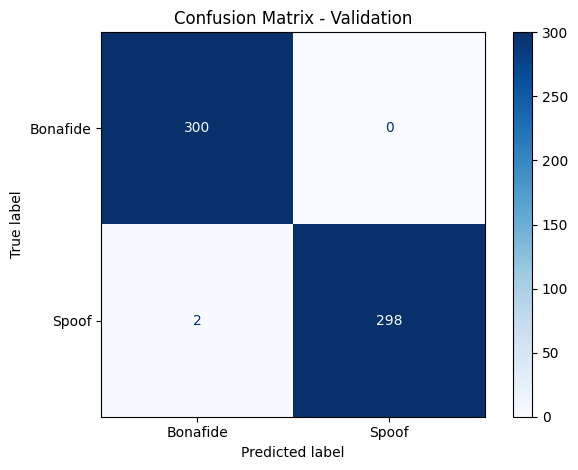

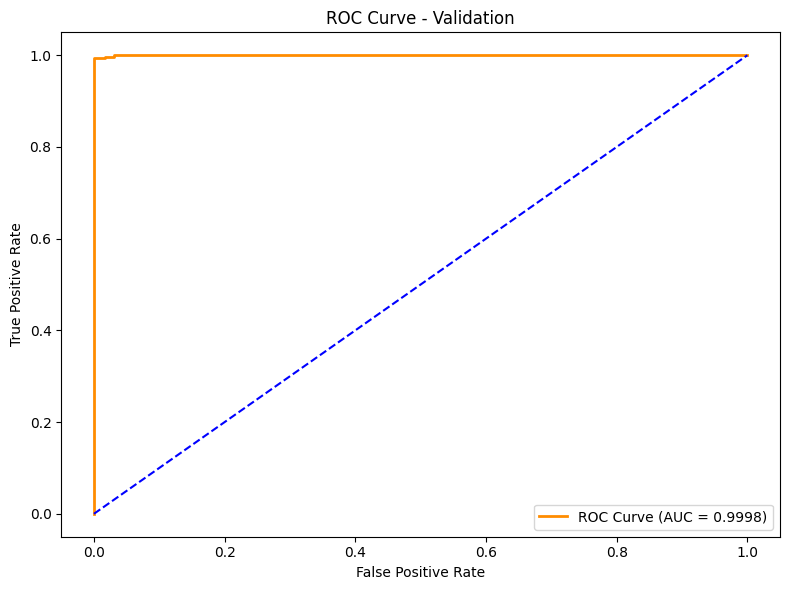

AUC: 0.9998
EER: 0.33%  |  Threshold: 0.6146


In [11]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt

plots_path = "/content/drive/MyDrive/DeepTrace_Audio/plots"
os.makedirs(plots_path, exist_ok=True)

def evaluate_set(model, loader, set_name="Validation"):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            outputs, _ = model(X_batch)
            probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
            preds = outputs.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())
            all_probs.extend(probs)

    print(f"\n{'='*50}")
    print(f"{set_name} Results")
    print(f"{'='*50}")
    print(classification_report(all_labels, all_preds,
          target_names=["Bonafide (Real)", "Spoof (Fake)"]))

    cm   = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=["Bonafide", "Spoof"])
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {set_name}")
    plt.tight_layout()
    plt.savefig(f"{plots_path}/confusion_{set_name.lower()}.png", dpi=150)
    plt.show()

    fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color="darkorange", lw=2,
             label=f"ROC Curve (AUC = {roc_auc:.4f})")
    plt.plot([0, 1], [0, 1], "b--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {set_name}")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(f"{plots_path}/roc_{set_name.lower()}.png", dpi=150)
    plt.show()
    print(f"AUC: {roc_auc:.4f}")

    frr     = 1 - tpr
    eer_idx = np.argmin(np.abs(fpr - frr))
    eer     = (fpr[eer_idx] + frr[eer_idx]) / 2
    print(f"EER: {eer*100:.2f}%  |  Threshold: {thresholds[eer_idx]:.4f}")

    return roc_auc, eer

# Run validation evaluation
val_auc, val_eer = evaluate_set(model_v2, val_loader_v2, "Validation")


Test Results
                 precision    recall  f1-score   support

Bonafide (Real)       0.98      0.99      0.99       300
   Spoof (Fake)       0.99      0.98      0.99       300

       accuracy                           0.99       600
      macro avg       0.99      0.99      0.99       600
   weighted avg       0.99      0.99      0.99       600



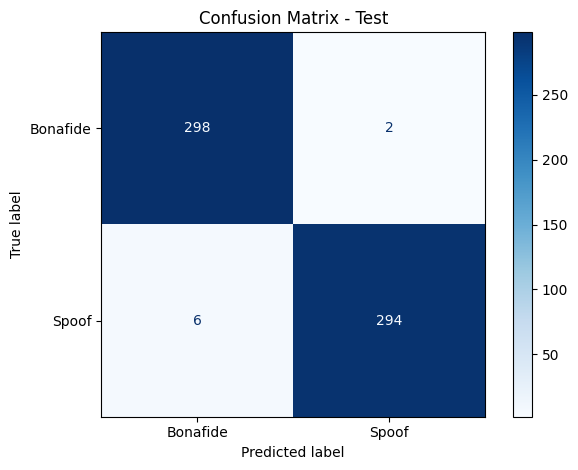

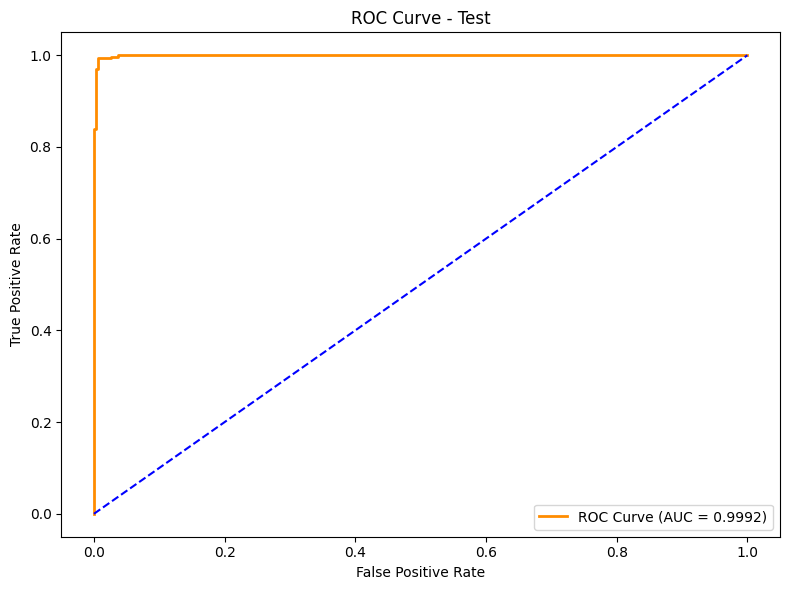

AUC: 0.9992
EER: 0.67%  |  Threshold: 0.0920


In [12]:
# Run test evaluation — this is the final performance on unseen data
test_auc, test_eer = evaluate_set(model_v2, test_loader_v2, "Test")

In [13]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "DeepTrace V1 (MFCC only)",
        "DeepTrace V2 (Multi-domain) — Validation",
        "DeepTrace V2 (Multi-domain) — Test"
    ],
    "Accuracy": ["99.65%", "98.00%", "TBD from output"],
    "AUC":      ["0.9999",  f"{val_auc:.4f}", f"{test_auc:.4f}"],
    "EER":      ["0.44%",   f"{val_eer*100:.2f}%", f"{test_eer*100:.2f}%"],
    "Dataset":  [
        "Imbalanced (90% fake)",
        "Balanced — Val split",
        "Balanced — Test split"
    ],
    "Domains":  [
        "1 (MFCC)",
        "5 (MFCC, Mel, F0, LPC, Breathing+Phase)",
        "5 (MFCC, Mel, F0, LPC, Breathing+Phase)"
    ],
    "Attention": ["No", "Yes", "Yes"],
    "Vocal Tract / Prosody": ["No", "Yes", "Yes"],
})

print(results.to_string(index=False))
results.to_csv(f"{plots_path}/final_results.csv", index=False)
print("\nFinal results saved to Drive!")

                                   Model        Accuracy    AUC   EER               Dataset                                 Domains Attention Vocal Tract / Prosody
                DeepTrace V1 (MFCC only)          99.65% 0.9999 0.44% Imbalanced (90% fake)                                1 (MFCC)        No                    No
DeepTrace V2 (Multi-domain) — Validation          98.00% 0.9998 0.33%  Balanced — Val split 5 (MFCC, Mel, F0, LPC, Breathing+Phase)       Yes                   Yes
      DeepTrace V2 (Multi-domain) — Test TBD from output 0.9992 0.67% Balanced — Test split 5 (MFCC, Mel, F0, LPC, Breathing+Phase)       Yes                   Yes

Final results saved to Drive!


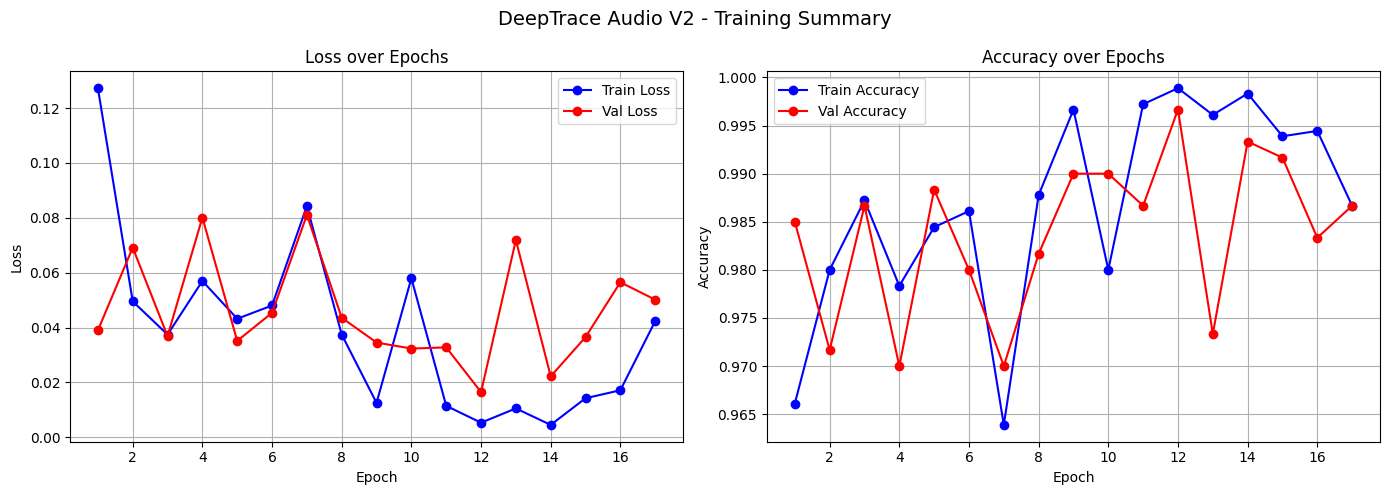

Training curves saved to Drive!


In [14]:
epochs = range(1, len(train_loss_hist) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs, train_loss_hist, 'b-o', label="Train Loss")
ax1.plot(epochs, val_loss_hist,   'r-o', label="Val Loss")
ax1.set_title("Loss over Epochs")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True)

ax2.plot(epochs, train_acc_hist, 'b-o', label="Train Accuracy")
ax2.plot(epochs, val_acc_hist,   'r-o', label="Val Accuracy")
ax2.set_title("Accuracy over Epochs")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()
ax2.grid(True)

plt.suptitle("DeepTrace Audio V2 - Training Summary", fontsize=14)
plt.tight_layout()
plt.savefig(f"{plots_path}/training_curves_v2.png", dpi=150)
plt.show()
print("Training curves saved to Drive!")